<a href="https://colab.research.google.com/github/Bivasgithub/Sea_Breeze_Front/blob/main/2_Sea_Breeze_Index_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SBI using V_onshore, Specific Humidity, and Temperature gradient**

In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_index(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    for col in ["Wind speed (m/s)", "Wind direction (°)", "Relative humidity (%)", "Temperature (°C)"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # df = df[
    #     (df.index.month == 6) &
    #     (df.index.day == 28)
    # ].between_time("06:00", "16:00")

    # For 2_year 2nd dataset
    df = df[
        (df.index.year == 2024) &
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "16:00")

    # Temperature gradient
    df = df.dropna()
    df["dT"] = df["Temperature (°C)"].diff()

## Onshore component of Wind Speed
    # Now apply deg2rad
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    # # Compute components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    alpha = np.deg2rad(100) # (Consider 90+10 degree)

    df["V_onshore"] = (df["u"] * np.sin(alpha)
    + df["v"] * np.cos(alpha))
    #df["V_onshore"] = u

    # Compute specific humidity
    T_K = df["Temperature (°C)"] + 273.15
    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (df["Relative humidity (%)"]*100.0 / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df["q_gkg"] = df["q"] * 1000 # gm/kg
    # Specific humidity tendency
    df["dq"] = df["q_gkg"].diff()

#### Working on it
    #df["dW"] = df["Wind speed (m/s)"].diff()
    df["dT_n"] = (df["dT"] - df["dT"].mean()) / df["dT"].std()
    df["dq_n"] = (df["dq"] - df["dq"].mean()) / df["dq"].std()
    df["V_n"] = (df["V_onshore"] - df["V_onshore"].mean()) / df["V_onshore"].std()

    # Weighted SBF_index
    df["SBF_index"] = 0.40*df["V_n"] + 0.35*df["dq_n"] - 0.25*df["dT_n"]

    # 99th percentile threshold
    threshold = df["SBF_index"].quantile(0.98)

    # Filtering conditions
    df["SBF_flag"] = (
        (df["SBF_index"] > threshold) &
        (df["V_onshore"] > 0) &   # +ve Onshore component
        (df["dT"] < 0)      # temperature drop
    )

    df["SBF_peak"] = (
        (df["SBF_index"] > df["SBF_index"].shift(1)) &
        (df["SBF_index"] > df["SBF_index"].shift(-1)) &
        (df["SBF_flag"])
    )

    df = df.dropna()

    return df, threshold


#file_path = "/content/Jova_data.xlsx"
file_path = "/content/Bet_Harava_data_2026051016.xlsx"

df_result, threshold = compute_sbf_index(file_path)

print("\n :: Sea Breeze Front Candidates :: \n")
print(df_result[df_result["SBF_flag"]][[
    "Temperature (°C)", "q_gkg", "V_onshore", "SBF_index"
]])

print("\n ::Peak Front Arrival Time:: \n")
print(df_result[df_result["SBF_peak"]].index)


 :: Sea Breeze Front Candidates :: 

                     Temperature (°C)      q_gkg  V_onshore  SBF_index
Date & Time (UTC)                                                     
2024-06-28 15:10:00              40.3  14.298914   8.764789   1.608434
2024-06-28 15:20:00              39.9  15.022489   8.987964   2.015812

 ::Peak Front Arrival Time:: 

DatetimeIndex(['2024-06-28 15:20:00'], dtype='datetime64[ns]', name='Date & Time (UTC)', freq=None)


In [ ]:
#print(df_result.head())

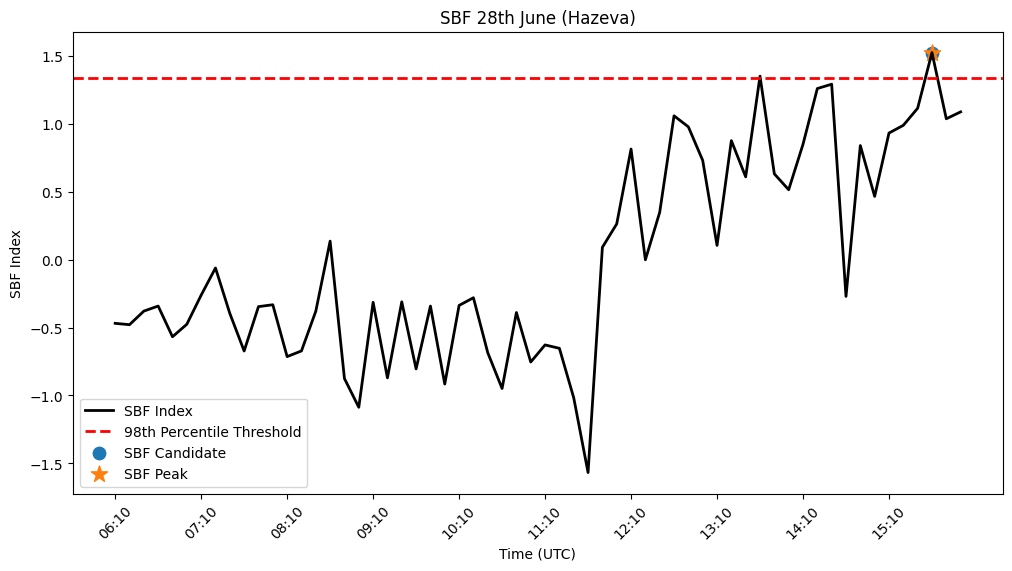

In [ ]:
import matplotlib.pyplot as plt

# PLOT SBF INDEX
plt.figure(figsize=(12,6))

# SBF index line
plt.plot(
    df_result.index,
    df_result["SBF_index"],
    linewidth=2,
    color='black',
    label="SBF Index"
)
# Threshold line
plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    color='red',
    label="98th Percentile Threshold"
)
# SBF detected points
plt.scatter(
    df_result[df_result["SBF_flag"]].index,
    df_result[df_result["SBF_flag"]]["SBF_index"],
    s=80,
    label="SBF Candidate"
)
# Peak points
plt.scatter(
    df_result[df_result["SBF_peak"]].index,
    df_result[df_result["SBF_peak"]]["SBF_index"],
    s=150,
    marker="*",
    label="SBF Peak"
)

# X-axis formatting
plt.xticks(df_result.index[::6], df_result.index.strftime("%H:%M")[::6], rotation=45)
plt.xlabel("Time (UTC)")
plt.ylabel("SBF Index")
plt.title("SBF 28th June (Hazeva)")
plt.legend()
#plt.grid(True)
plt.savefig("SBF_Index_28th_June_Hazeva.png", dpi=300, bbox_inches='tight')
plt.show()

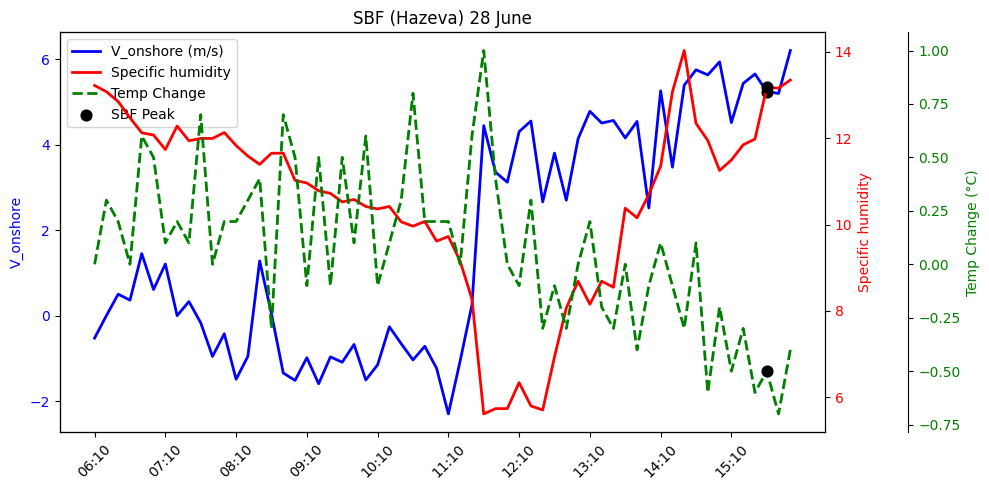

In [ ]:
import matplotlib.pyplot as plt

def plot_combined_sbf(df):

    peaks = df[df["SBF_peak"]]

    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(df.index, df["V_onshore"],
             color="blue", label="V_onshore (m/s)", linewidth=2)

    # Mark peaks
    ax1.scatter(peaks.index, peaks["V_onshore"],
                color="black", s=60, zorder=5, label="SBF Peak")
    ax1.set_ylabel("V_onshore", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")



    ax2 = ax1.twinx()
    ax2.plot(df.index, df["q_gkg"],
             color="red", label="Specific humidity", linewidth=2)
    ax2.scatter(peaks.index, peaks["q_gkg"],
                color="black", s=60, zorder=5)
    ax2.set_ylabel("Specific humidity", color="red")
    ax2.tick_params(axis='y', labelcolor="red")



    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(df.index, df["dT"],
             color="green", linestyle="--", label="Temp Change", linewidth=2)
    ax3.scatter(peaks.index, peaks["dT"],
                color="black", s=60, zorder=5)
    ax3.set_ylabel("Temp Change (°C)", color="green")
    ax3.tick_params(axis='y', labelcolor="green")

    # X-axis formatting
    ax1.set_xticks(df.index[::6])
    ax1.set_xticklabels(df.index[::6].strftime("%H:%M"), rotation=45)

    plt.title("SBF (Hazeva) 28 June")

    # Combined legend
    lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
    labels = [l.get_label() for l in lines]

    # Add SBF Peak manually (since scatter not always included)
    labels.append("SBF Peak")
    lines.append(ax1.collections[0])
    ax1.legend(lines, labels, loc="best")

    # Layout & Save
    plt.tight_layout()
    plt.savefig("SBF_Hazeva_28_june.jpg", dpi=300, bbox_inches='tight')
    plt.show()

# Call the function
plot_combined_sbf(df_result)

In [ ]:
print(df_result[df_result["SBF_flag"]]["SBF_index"])

Date & Time (UTC)
2025-07-10 12:30:00    1.562895
Name: SBF_index, dtype: float64


In [ ]:
print(df_result["SBF_flag"].value_counts())

SBF_flag
False    72
True      1
Name: count, dtype: int64


In [ ]:
# import pandas as pd
# df = pd.read_excel("/content/Jova_data.xlsx", engine="openpyxl")
# print(df.columns.tolist())

In [ ]:
print(df_result.head())

                     Wind speed (m/s)  Wind direction (°)  \
Date & Time (UTC)                                           
2025-07-10 07:10:00               4.8               238.0   
2025-07-10 07:20:00               4.9               235.0   
2025-07-10 07:30:00               5.2               234.0   
2025-07-10 07:40:00               5.3               238.0   
2025-07-10 07:50:00               5.5               238.0   

                     Relative humidity (%)  Temperature (°C)   dT         u  \
Date & Time (UTC)                                                             
2025-07-10 07:10:00                   72.0              28.1  1.3  4.070631   
2025-07-10 07:20:00                   72.0              28.1  0.0  4.013845   
2025-07-10 07:30:00                   72.0              28.2  0.1  4.206888   
2025-07-10 07:40:00                   72.0              28.3  0.1  4.494655   
2025-07-10 07:50:00                   73.0              28.3  0.0  4.664265   

                  

# **SBI using V_onshore, Specific Humidity, Gust Wind Speed, and Temperature gradient**

In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_index(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Wind direction (°)",
        "Gust wind speed (m/s)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    for col in ["Wind speed (m/s)", "Wind direction (°)", "Gust wind speed (m/s)", "Relative humidity (%)", "Temperature (°C)"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    # df = df[
    #     (df.index.month == 7) &
    #     (df.index.day == 15)
    # ].between_time("06:00", "15:30")

    # For 2 year 2nd dataset
    df = df[
        (df.index.year == 2024) &
        (df.index.month == 7) &
        (df.index.day == 15)
    ].between_time("06:00", "16:00")

    # Temperature gradient
    df = df.dropna()
    df["dT"] = df["Temperature (°C)"].diff()

## Onshore component of Wind Speed
    # Now apply deg2rad
    theta = np.deg2rad(df["Wind direction (°)"].values)
    V = df["Wind speed (m/s)"].values
    # # Compute components
    u = -V * np.sin(theta)
    v = -V * np.cos(theta)
    df["u"] = u
    df["v"] = v
    alpha = np.deg2rad(100) # (Consider 90+10 degree)

    df["V_onshore"] = (df["u"] * np.sin(alpha)
    + df["v"] * np.cos(alpha))
    #df["V_onshore"] = u

    # Gust Wind Speed
    G_V = df["Gust wind speed (m/s)"]

    # Compute specific humidity
    T_K = df["Temperature (°C)"] + 273.15
    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    df["q"] = (df["Relative humidity (%)"]*100.0 / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df["q_gkg"] = df["q"] * 1000 # gm/kg
    # Specific humidity tendency
    df["dq"] = df["q_gkg"].diff()

#### Working on it
    #df["dW"] = df["Wind speed (m/s)"].diff()
    df["dT_n"] = (df["dT"] - df["dT"].mean()) / df["dT"].std()
    df["dq_n"] = (df["dq"] - df["dq"].mean()) / df["dq"].std()
    df["V_n"] = (df["V_onshore"] - df["V_onshore"].mean()) / df["V_onshore"].std()
    ## Additional term
    df["G_V_n"] = (G_V - G_V.mean()) / G_V.std()

    # Weighted SBF_index [0.4, 0.3, 0.15, 0.15]
    df["SBF_index"] = 0.40*df["V_n"] + 0.3*df["dq_n"] - 0.15*df["dT_n"] + 0.15*df["G_V_n"]

    # 99th percentile threshold
    threshold = df["SBF_index"].quantile(0.98)

    # Filtering conditions
    df["SBF_flag"] = (
        (df["SBF_index"] > threshold) &
        (df["V_onshore"] > 0) &   # +ve Onshore component
        (df["dT"] < 0)      # temperature drop
    )

    df["SBF_peak"] = (
        (df["SBF_index"] > df["SBF_index"].shift(1)) &
        (df["SBF_index"] > df["SBF_index"].shift(-1)) &
        (df["SBF_flag"])
    )

    df = df.dropna()

    return df, threshold


file_path = "/content/Bet_Harava_data_2026051016.xlsx"
#file_path = "/content/Hazeva_data_20260510111.xlsx"

df_result, threshold = compute_sbf_index(file_path)

print("\n :: Sea Breeze Front Candidates :: \n")
print(df_result[df_result["SBF_flag"]][[
    "Temperature (°C)", "q_gkg", "V_onshore", "Gust wind speed (m/s)", "SBF_index"
]])

print("\n ::Peak Front Arrival Time:: \n")
print(df_result[df_result["SBF_peak"]].index)


 :: Sea Breeze Front Candidates :: 

                     Temperature (°C)      q_gkg  V_onshore  \
Date & Time (UTC)                                             
2024-07-15 15:40:00              38.7  15.508154   8.017184   
2024-07-15 15:50:00              38.5  15.815397   7.459177   

                     Gust wind speed (m/s)  SBF_index  
Date & Time (UTC)                                      
2024-07-15 15:40:00                   10.5   1.919561  
2024-07-15 15:50:00                    9.6   1.311240  

 ::Peak Front Arrival Time:: 

DatetimeIndex(['2024-07-15 15:40:00'], dtype='datetime64[ns]', name='Date & Time (UTC)', freq=None)


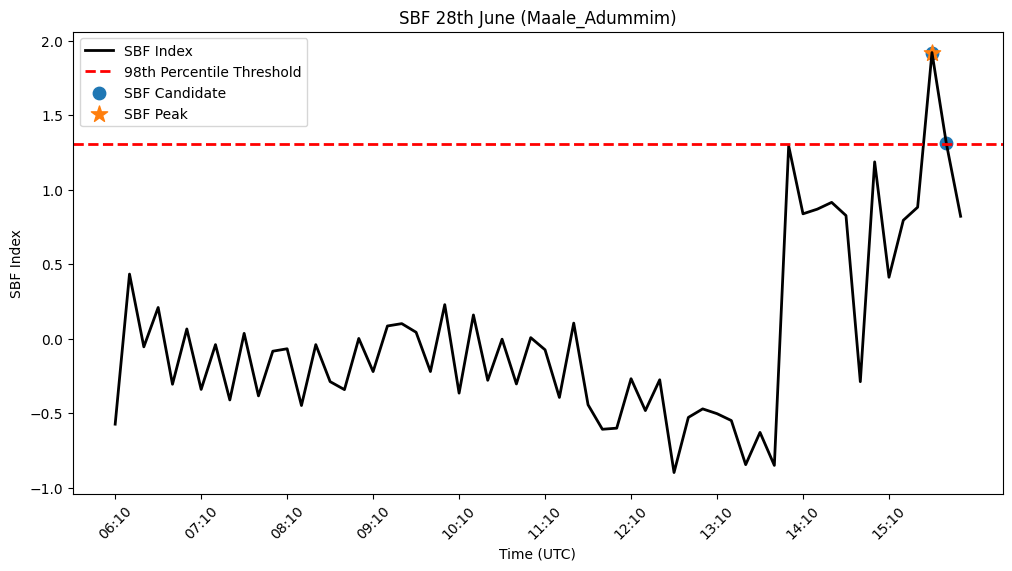

In [ ]:
import matplotlib.pyplot as plt

# PLOT SBF INDEX
plt.figure(figsize=(12,6))

# SBF index line
plt.plot(
    df_result.index,
    df_result["SBF_index"],
    linewidth=2,
    color='black',
    label="SBF Index"
)
# Threshold line
plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    color='red',
    label="98th Percentile Threshold"
)
# SBF detected points
plt.scatter(
    df_result[df_result["SBF_flag"]].index,
    df_result[df_result["SBF_flag"]]["SBF_index"],
    s=80,
    label="SBF Candidate"
)
# Peak points
plt.scatter(
    df_result[df_result["SBF_peak"]].index,
    df_result[df_result["SBF_peak"]]["SBF_index"],
    s=150,
    marker="*",
    label="SBF Peak"
)

# X-axis formatting
plt.xticks(df_result.index[::6], df_result.index.strftime("%H:%M")[::6], rotation=45)
plt.xlabel("Time (UTC)")
plt.ylabel("SBF Index")
plt.title("SBF 28th June (Maale_Adummim)")
plt.legend()
#plt.grid(True)
plt.savefig("SBF_Index_28th_June_Maale.png", dpi=300, bbox_inches='tight')
plt.show()

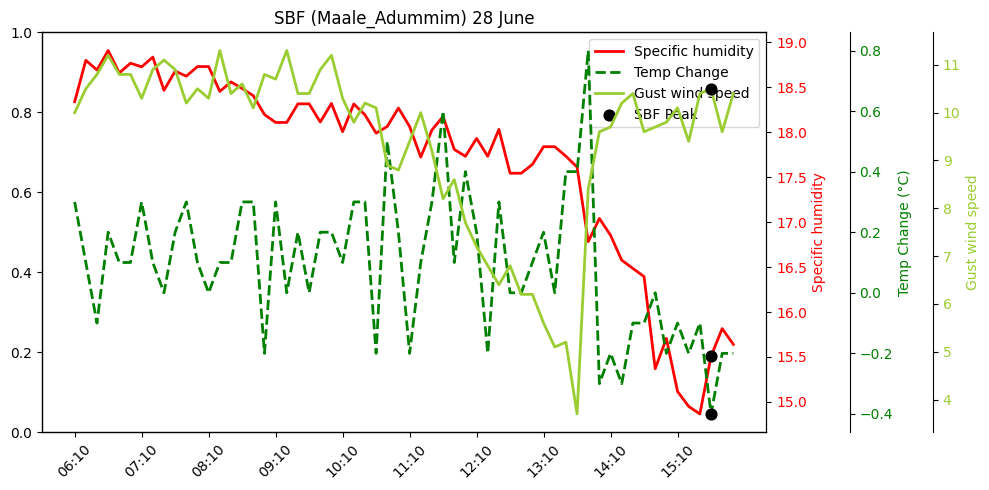

In [ ]:
import matplotlib.pyplot as plt

def plot_combined_sbf(df):

    peaks = df[df["SBF_peak"]]

    fig, ax1 = plt.subplots(figsize=(10,5))

    # ax1.plot(df.index, df["V_onshore"],
    #          color="blue", label="V_onshore (m/s)", linewidth=2)

    # # Mark peaks
    # ax1.scatter(peaks.index, peaks["V_onshore"],
    #             color="black", s=60, zorder=5, label="SBF Peak")
    # ax1.set_ylabel("V_onshore", color="blue")
    # ax1.tick_params(axis='y', labelcolor="blue")


    ax2 = ax1.twinx()
    ax2.plot(df.index, df["q_gkg"],
             color="red", label="Specific humidity", linewidth=2)
    ax2.scatter(peaks.index, peaks["q_gkg"],
                color="black", s=60, zorder=5)
    ax2.set_ylabel("Specific humidity", color="red")
    ax2.tick_params(axis='y', labelcolor="red")


    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(df.index, df["dT"],
             color="green", linestyle="--", label="Temp Change", linewidth=2)
    ax3.scatter(peaks.index, peaks["dT"],
                color="black", s=60, zorder=5)
    ax3.set_ylabel("Temp Change (°C)", color="green")
    ax3.tick_params(axis='y', labelcolor="green")

    ax4 = ax1.twinx()
    ax4.spines["right"].set_position(("outward", 120))
    ax4.plot(df.index, df["Gust wind speed (m/s)"],
             color="yellowgreen", label="Gust wind speed", linewidth=2)
    ax4.scatter(peaks.index, peaks["Gust wind speed (m/s)"],
                color="black", s=60, zorder=5)
    ax4.set_ylabel("Gust wind speed", color="yellowgreen")
    ax4.tick_params(axis='y', labelcolor="yellowgreen")


    # X-axis formatting
    ax1.set_xticks(df.index[::6])
    ax1.set_xticklabels(df.index[::6].strftime("%H:%M"), rotation=45)

    plt.title("SBF (Maale_Adummim) 28 June")

    # Combined legend ## ax1.get_lines() +
    lines =  ax2.get_lines() + ax3.get_lines() + ax4.get_lines()
    labels = [l.get_label() for l in lines]

    # Add SBF Peak manually (since scatter not always included)
    labels.append("SBF Peak")
    lines.append(ax2.collections[0])
    ax2.legend(lines, labels, loc="best")

    # Layout & Save
    plt.tight_layout()
    plt.savefig("SBF_Maale_28_june.jpg", dpi=300, bbox_inches='tight')
    plt.show()

# Call the function
plot_combined_sbf(df_result)

In [ ]:
#print(df_result.head())